# Tiny 3D dense-anchor sanity check for landmark detection

This Colab notebook implements the tutorial up to **Step 14**, with one extra simplification requested here:

- landmarks are treated as tiny 3D boxes,
- a small dense-anchor detector predicts **multiclass landmark scores per anchor**,
- the regression branch still predicts a small 3D box offset,
- there is still **no ROI head / second-stage crop classifier** yet.

So this is **not a full Faster R-CNN**. It is closer to a tiny 3D anchor detector:

```text
image -> 3D backbone -> dense anchor head -> class scores + box deltas
```

The class branch predicts:

```text
0 = background
1..L = landmark IDs
```


## 1. Install dependencies


In [1]:
!pip -q install pynrrd pandas torchio
!pip3 -q install torch torchvision

## 2. Imports and device


In [2]:
from dataclasses import dataclass
import os
import random
from typing import Optional, Sequence, Tuple, List

import numpy as np
import pandas as pd
import nrrd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from tqdm import tqdm


In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 3. Configuration

Edit the paths and column names. Start with `overfit_n = 1`, then try `5`, then `None`.


In [ ]:
@dataclass
class CFG:
    # paths
    root: str = "/media/yusuf/HDD 4TB/DATA"
    dataframe_csv: str = "/media/yusuf/HDD 4TB/DATA/sinMaternitat__fold3.csv"
    image_col: str = "mscan"
    landmark_col: str = "mcsv"

    # Landmark CSV coordinate columns. If None, first 3 numeric columns are used.
    landmark_columns: Optional[Tuple[str, str, str]] = ("x", "y", "z")

    # data
    radius: float = 4.0
    num_landmarks: int = 19
    normalize_image: bool = True
    batch_size: int = 1
    num_workers: int = 0
    val_fraction: float = 0.2
    # Optional resize after loading. Keep None for the first coordinate sanity check.
    # Example: target_size_dhw = (128, 128, 128)
    target_size_dhw: Optional[Tuple[int, int, int]] = None

    # anchors/model
    anchor_sizes: Tuple[float, ...] = (4, 6, 8, 10, 12)
    backbone_channels: int = 32

    # Anchor matching
    positive_iou: float = 0.20
    negative_iou: float = 0.05
    anchor_batch_size: int = 256
    positive_fraction: float = 0.50

    # optimization
    epochs: int = 50
    lr: float = 1e-4
    weight_decay: float = 1e-4
    val_interval: int = 5

    # inference
    topk_proposals: int = 200
    score_threshold: float = 0.0  # keep 0.0 for debugging; increase later

cfg = CFG()
cfg


CFG(root='/media/yusuf/HDD 4TB/DATA', dataframe_csv='/media/yusuf/HDD 4TB/DATA/sinMaternitat__fold3.csv', image_col='mscan', landmark_col='mcsv', landmark_columns=('x', 'y', 'z'), radius=4.0, num_landmarks=19, normalize_image=True, batch_size=1, num_workers=0, val_fraction=0.2, target_size_dhw=None, anchor_sizes=(4, 6, 8, 10, 12), backbone_channels=32, positive_iou=0.2, negative_iou=0.05, anchor_batch_size=256, positive_fraction=0.5, epochs=50, lr=0.0001, weight_decay=0.0001, val_interval=5, topk_proposals=200, score_threshold=0.0)

## 4. Load dataframe and create train/validation split


In [5]:
def update_dataframe(dataframe, root):
    # Construct full file paths by joining base paths with relative paths
    paths = dataframe['mscan'].apply(lambda x: os.path.join(root, x))
    # Create a boolean mask for existing files
    mask = paths.apply(os.path.exists)
    # Filter DataFrame by mask and reset index
    dataframe = dataframe[mask].reset_index(drop=True)
    # Clear nonfrontal
    dataframe = dataframe[~dataframe['nonfrontal_after_rot']].reset_index(drop=True)
    # Clear set = -1 
    dataframe = dataframe[dataframe['set'] != -1].reset_index(drop=True)
    return dataframe

In [6]:
df = pd.read_csv(cfg.dataframe_csv).reset_index(drop=True)
df = update_dataframe(df, cfg.root)
print(df.head())
print("number of samples:", len(df))
print("columns:", list(df.columns))

assert cfg.image_col in df.columns, f"Missing image column: {cfg.image_col}"
assert cfg.landmark_col in df.columns, f"Missing landmark column: {cfg.landmark_col}"


       nsid  npid opid        week      osid  \
0  10012001  1001    1  20 semanas  1-20s-01   
1  10012005  1001    1  20 semanas  1-20s-05   
2  10012009  1001    1  20 semanas  1-20s-09   
3  10012604  1001    1  26 semanas  1-26s-04   
4  10012609  1001    1  26 semanas  1-26s-09   

                                    fcaso  \
0  /media/yusuf/HDD 4TB/Casos Mar/Casos/1   
1  /media/yusuf/HDD 4TB/Casos Mar/Casos/1   
2  /media/yusuf/HDD 4TB/Casos Mar/Casos/1   
3  /media/yusuf/HDD 4TB/Casos Mar/Casos/1   
4  /media/yusuf/HDD 4TB/Casos Mar/Casos/1   

                                               fweek  \
0  /media/yusuf/HDD 4TB/Casos Mar/Casos/1/20 semanas   
1  /media/yusuf/HDD 4TB/Casos Mar/Casos/1/20 semanas   
2  /media/yusuf/HDD 4TB/Casos Mar/Casos/1/20 semanas   
3  /media/yusuf/HDD 4TB/Casos Mar/Casos/1/26 semanas   
4  /media/yusuf/HDD 4TB/Casos Mar/Casos/1/26 semanas   

                                               fscan  os0  os1  ...  \
0  /media/yusuf/HDD 4TB/Casos Ma

In [7]:
train_idx = df[df["set"] == 0].index.to_numpy()
val_idx = df[df["set"] == 1].index.to_numpy()

# For the first sanity check, overfit on the first N training volumes and validate on the same volumes.
# Set cfg.overfit_n = None to use the normal train/validation split.
# if cfg.overfit_n is not None:
#     train_idx = train_idx[: cfg.overfit_n]
#     val_idx = train_idx.copy()

print("train_idx:", train_idx[:10], "total", len(train_idx))
print("val_idx:", val_idx[:10], "total", len(val_idx))


train_idx: [ 0  1  2  3  4  5  6  7 13 14] total 525
val_idx: [ 8  9 10 11 12 26 27 28 29 30] total 170


## 5. NRRD and landmark loading helpers

Your original `extract_image` is preserved, but the tensor conversion explicitly transposes `[x,y,z] -> [z,y,x]`.


In [48]:
def extract_image(filename):
    """Extract NRRD image into a 3D numpy array [x, y, z]."""
    data, header = nrrd.read(filename)
    if len(data.shape) == 4:
        data = data[:, :, :, 0]
    return data, header


def image_xyz_to_tensor_cdhw(data_xyz: np.ndarray, normalize: bool = False) -> torch.Tensor:
    """Convert numpy [x,y,z] to torch [C,D,H,W] = [C,z,y,x]."""
    data_dhw = np.transpose(data_xyz, (2, 1, 0)).copy()
    image = torch.from_numpy(data_dhw).float().unsqueeze(0)

    if normalize:
        image = (image - image.mean()) / image.std().clamp_min(1e-6)

    return image


def load_landmarks_csv(csv_path: str, landmark_columns=None) -> torch.Tensor:
    """Return landmarks as Tensor [L,3] in xyz order."""
    lm_df = pd.read_csv(csv_path)

    if landmark_columns is not None:
        missing = [c for c in landmark_columns if c not in lm_df.columns]
        if missing:
            raise ValueError(f"Missing landmark columns {missing} in {csv_path}")
        arr = lm_df.loc[:, list(landmark_columns)].to_numpy(dtype=np.float32)
    else:
        numeric = lm_df.select_dtypes(include=[np.number])
        if numeric.shape[1] < 3:
            raise ValueError(
                f"Expected at least 3 numeric landmark columns in {csv_path}. "
                f"Found columns: {list(lm_df.columns)}"
            )
        arr = numeric.iloc[:, :3].to_numpy(dtype=np.float32)
    
    label_names = lm_df.loc[:, "label"].values
    return torch.from_numpy(arr).float(), label_names


## 6. Landmark checks and tiny 3D boxes


In [44]:
def check_landmarks_xyz(points: torch.Tensor, image_shape: Sequence[int], info=None):
    """
    points: [N,3] in xyz order
    image_shape: [C,D,H,W]
    """
    _, D, H, W = image_shape
    x, y, z = points[:, 0], points[:, 1], points[:, 2]

    assert torch.all((x >= 0) & (x < W)), f"x outside width: range=({x.min():.2f},{x.max():.2f}), W={W}, info={info}"
    assert torch.all((y >= 0) & (y < H)), f"y outside height: range=({y.min():.2f},{y.max():.2f}), H={H}, info={info}"
    assert torch.all((z >= 0) & (z < D)), f"z outside depth: range=({z.min():.2f},{z.max():.2f}), D={D}, info={info}"


def landmarks_to_boxes_3d(points_xyz: torch.Tensor, image_shape: Sequence[int], radius: float = 3.0):
    """Convert [x,y,z] points to boxes [x1,y1,z1,x2,y2,z2]."""
    _, D, H, W = image_shape
    x, y, z = points_xyz[:, 0], points_xyz[:, 1], points_xyz[:, 2]

    x1 = (x - radius).clamp(0, W - 1)
    y1 = (y - radius).clamp(0, H - 1)
    z1 = (z - radius).clamp(0, D - 1)
    x2 = (x + radius).clamp(0, W - 1)
    y2 = (y + radius).clamp(0, H - 1)
    z2 = (z + radius).clamp(0, D - 1)

    return torch.stack([x1, y1, z1, x2, y2, z2], dim=1).float()


def boxes_to_centers_3d(boxes: torch.Tensor):
    x = 0.5 * (boxes[:, 0] + boxes[:, 3])
    y = 0.5 * (boxes[:, 1] + boxes[:, 4])
    z = 0.5 * (boxes[:, 2] + boxes[:, 5])
    return torch.stack([x, y, z], dim=1)


## 8. Dataset and dataloaders

Fixes from your snippet:

- `__len__` uses `len(self.dataframe)`, not `self.samples`.
- DataFrame landmarks are converted to tensor.
- Transform receives both image and landmarks.
- Labels are `1..L`, not `0..L` or length `L+1`.


In [49]:
class LandmarkDetection3DDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        root: str,
        image_col: str = "mscan",
        landmark_col: str = "mcsv",
        landmark_columns=None,
        radius: float = 4.0,
        transform=None,
        normalize_image: bool = True,
        num_landmarks: Optional[int] = None,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root = root
        self.image_col = image_col
        self.landmark_col = landmark_col
        self.landmark_columns = landmark_columns
        self.radius = radius
        self.transform = transform
        self.normalize_image = normalize_image
        self.num_landmarks = num_landmarks

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.root, row[self.image_col])
        lmk_path = os.path.join(self.root, row[self.landmark_col])

        volume_xyz, header = extract_image(image_path)
        image = image_xyz_to_tensor_cdhw(volume_xyz, normalize=self.normalize_image)
        points, landmark_names = load_landmarks_csv(lmk_path, landmark_columns=self.landmark_columns)

        if self.num_landmarks is not None and points.shape[0] != self.num_landmarks:
            raise ValueError(
                f"Expected {self.num_landmarks} landmarks, got {points.shape[0]} in {lmk_path}. "
                "Update cfg.num_landmarks or check the landmark CSV."
            )

        if self.transform is not None:
            image, points = self.transform(image, points)

        check_landmarks_xyz(points, image.shape, info=lmk_path)

        boxes = landmarks_to_boxes_3d(points, image.shape, radius=self.radius)
        labels = torch.arange(1, points.shape[0] + 1).long()

        target = {
            "boxes": boxes,
            "labels": labels,
            "points": points,
            "image_path": image_path,
            "landmark_path": lmk_path,
            "landmark_names": landmark_names
        }
        return image, target, row


def detection_collate(batch):
    images, targets, rows = zip(*batch)
    return list(images), list(targets), list(rows)


In [50]:
train_dataset = LandmarkDetection3DDataset(
    dataframe=df.iloc[train_idx].reset_index(drop=True),
    root=cfg.root,
    image_col=cfg.image_col,
    landmark_col=cfg.landmark_col,
    landmark_columns=cfg.landmark_columns,
    radius=cfg.radius,
    transform=None,
    normalize_image=cfg.normalize_image,
    num_landmarks=cfg.num_landmarks,
)

val_dataset = LandmarkDetection3DDataset(
    dataframe=df.iloc[val_idx].reset_index(drop=True),
    root=cfg.root,
    image_col=cfg.image_col,
    landmark_col=cfg.landmark_col,
    landmark_columns=cfg.landmark_columns,
    radius=cfg.radius,
    transform=None,
    normalize_image=cfg.normalize_image,
    num_landmarks=cfg.num_landmarks,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    collate_fn=detection_collate,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=detection_collate,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))


train batches: 525
val batches: 170


## 9. Smoke-test one sample


In [103]:
smoke_index = 0
image0, target0, row0 = train_dataset[smoke_index]
print("info:", row0['fcaso'])
print("image shape [C,D,H,W]:", tuple(image0.shape))
print("points shape:", tuple(target0["points"].shape))
print("boxes shape:", tuple(target0["boxes"].shape))
print("first 3 points [x,y,z]:")
print(target0["points"][:3])
print("first 3 boxes [x1,y1,z1,x2,y2,z2]:")
print(target0["boxes"][:3])
print("----------------- GT LOOKUP TABLE ---------------- \n")
lookup = pd.DataFrame(target0["landmark_names"])
lookup["categorical"] = np.arange(1,20)
lookup.set_index("categorical", inplace=True)
print(lookup)
print("-------------------------------------------------- \n")
lookup_dict = lookup.to_dict()[0]
print(lookup_dict)
centers0 = boxes_to_centers_3d(target0["boxes"])
print("max |box center - point|:", (centers0 - target0["points"]).abs().max().item())


info: /media/yusuf/HDD 4TB/Casos Mar/Casos/1
image shape [C,D,H,W]: (1, 128, 128, 128)
points shape: (19, 3)
boxes shape: (19, 6)
first 3 points [x,y,z]:
tensor([[48.8101, 66.9164, 74.1291],
        [57.8631, 63.9613, 73.7393],
        [64.0000, 62.0468, 75.6946]])
first 3 boxes [x1,y1,z1,x2,y2,z2]:
tensor([[44.8101, 62.9164, 70.1291, 52.8101, 70.9164, 78.1291],
        [53.8631, 59.9613, 69.7393, 61.8631, 67.9613, 77.7393],
        [60.0000, 58.0468, 71.6946, 68.0000, 66.0468, 79.6946]])
----------------- GT LOOKUP TABLE ---------------- 

                0
categorical      
1             exR
2             enR
3               n
4             enL
5             exL
6             acR
7              aR
8             prn
9              aL
10            acL
11             sn
12            chR
13           cphR
14             ls
15           cphL
16            chL
17             li
18             sl
19             pg
-------------------------------------------------- 

{1: 'exR', 2: 'enR', 3

In [55]:
for (images, targets, rows) in tqdm(train_loader):
    pass

for (images, targets, rows) in tqdm(val_loader):
    pass

100%|██████████| 170/170 [00:01<00:00, 102.11it/s]


## 10. 3D box utilities


In [14]:
def box_iou_3d(boxes1: torch.Tensor, boxes2: torch.Tensor, eps: float = 1e-6):
    b1 = boxes1[:, None, :]
    b2 = boxes2[None, :, :]

    inter_x1 = torch.maximum(b1[..., 0], b2[..., 0])
    inter_y1 = torch.maximum(b1[..., 1], b2[..., 1])
    inter_z1 = torch.maximum(b1[..., 2], b2[..., 2])
    inter_x2 = torch.minimum(b1[..., 3], b2[..., 3])
    inter_y2 = torch.minimum(b1[..., 4], b2[..., 4])
    inter_z2 = torch.minimum(b1[..., 5], b2[..., 5])

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_d = (inter_z2 - inter_z1).clamp(min=0)
    inter = inter_w * inter_h * inter_d

    vol1 = (
        (boxes1[:, 3] - boxes1[:, 0]).clamp(min=0)
        * (boxes1[:, 4] - boxes1[:, 1]).clamp(min=0)
        * (boxes1[:, 5] - boxes1[:, 2]).clamp(min=0)
    )
    vol2 = (
        (boxes2[:, 3] - boxes2[:, 0]).clamp(min=0)
        * (boxes2[:, 4] - boxes2[:, 1]).clamp(min=0)
        * (boxes2[:, 5] - boxes2[:, 2]).clamp(min=0)
    )

    union = vol1[:, None] + vol2[None, :] - inter
    return inter / (union + eps)


def box_center_size_3d(boxes: torch.Tensor):
    x1, y1, z1, x2, y2, z2 = boxes.unbind(dim=1)
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    cz = 0.5 * (z1 + z2)
    w = (x2 - x1).clamp(min=1e-6)
    h = (y2 - y1).clamp(min=1e-6)
    d = (z2 - z1).clamp(min=1e-6)
    return cx, cy, cz, w, h, d


def encode_boxes_3d(gt_boxes: torch.Tensor, anchors: torch.Tensor):
    gx, gy, gz, gw, gh, gd = box_center_size_3d(gt_boxes)
    ax, ay, az, aw, ah, ad = box_center_size_3d(anchors)
    tx = (gx - ax) / aw
    ty = (gy - ay) / ah
    tz = (gz - az) / ad
    tw = torch.log(gw / aw)
    th = torch.log(gh / ah)
    td = torch.log(gd / ad)
    return torch.stack([tx, ty, tz, tw, th, td], dim=1)


def decode_boxes_3d(deltas: torch.Tensor, anchors: torch.Tensor):
    tx, ty, tz, tw, th, td = deltas.unbind(dim=1)
    ax, ay, az, aw, ah, ad = box_center_size_3d(anchors)

    px = tx * aw + ax
    py = ty * ah + ay
    pz = tz * ad + az
    pw = torch.exp(tw.clamp(max=4.0)) * aw
    ph = torch.exp(th.clamp(max=4.0)) * ah
    pd = torch.exp(td.clamp(max=4.0)) * ad

    x1 = px - 0.5 * pw
    y1 = py - 0.5 * ph
    z1 = pz - 0.5 * pd
    x2 = px + 0.5 * pw
    y2 = py + 0.5 * ph
    z2 = pz + 0.5 * pd
    return torch.stack([x1, y1, z1, x2, y2, z2], dim=1)


def clip_boxes_3d(boxes: torch.Tensor, image_shape: Sequence[int]):
    boxes = boxes.clone()
    _, D, H, W = image_shape
    boxes[:, 0] = boxes[:, 0].clamp(0, W - 1)
    boxes[:, 3] = boxes[:, 3].clamp(0, W - 1)
    boxes[:, 1] = boxes[:, 1].clamp(0, H - 1)
    boxes[:, 4] = boxes[:, 4].clamp(0, H - 1)
    boxes[:, 2] = boxes[:, 2].clamp(0, D - 1)
    boxes[:, 5] = boxes[:, 5].clamp(0, D - 1)
    return boxes


## 11. 3D anchor generation


In [15]:
def generate_anchors_3d(
    feature_shape: Tuple[int, int, int],
    stride: int,
    sizes: Sequence[float],
    device: torch.device,
):
    Df, Hf, Wf = feature_shape

    z_centers = (torch.arange(Df, device=device) + 0.5) * stride
    y_centers = (torch.arange(Hf, device=device) + 0.5) * stride
    x_centers = (torch.arange(Wf, device=device) + 0.5) * stride

    zz, yy, xx = torch.meshgrid(z_centers, y_centers, x_centers, indexing="ij")
    centers = torch.stack([xx, yy, zz], dim=-1).reshape(-1, 3)

    all_anchors = []
    for s in sizes:
        half = float(s) / 2.0
        x, y, z = centers[:, 0], centers[:, 1], centers[:, 2]
        anchors = torch.stack(
            [x - half, y - half, z - half, x + half, y + half, z + half],
            dim=1,
        )
        all_anchors.append(anchors)

    return torch.cat(all_anchors, dim=0)


## 12. Multiclass anchor matching and loss

This replaces binary RPN objectness with a **multiclass anchor score**:

```text
0 = background
1..num_landmarks = landmark class
```

Regression is still class-agnostic and is trained only for positive anchors.


In [16]:
def match_anchors_to_gt_multiclass(
    anchors: torch.Tensor,
    gt_boxes: torch.Tensor,
    gt_labels: torch.Tensor,
    positive_iou: float = 0.20,
    negative_iou: float = 0.05,
):
    """
    Match anchors to GT boxes and create multiclass targets.

    returns:
        matched_gt_idx: [N], index of matched GT box for each anchor
        class_targets: [N]
            -1 = ignore
             0 = background
             1..L = landmark class labels
    """
    if gt_boxes.numel() == 0:
        class_targets = torch.zeros((anchors.shape[0],), dtype=torch.long, device=anchors.device)
        matched_gt_idx = torch.zeros((anchors.shape[0],), dtype=torch.long, device=anchors.device)
        return matched_gt_idx, class_targets

    ious = box_iou_3d(anchors, gt_boxes)
    max_iou, matched_gt_idx = ious.max(dim=1)

    # Start as ignore.
    class_targets = torch.full(
        (anchors.shape[0],),
        -1,
        dtype=torch.long,
        device=anchors.device,
    )

    # Background anchors.
    class_targets[max_iou < negative_iou] = 0

    # Positive anchors get the class label of their matched GT landmark.
    positive = max_iou >= positive_iou
    class_targets[positive] = gt_labels[matched_gt_idx[positive]]

    # Force at least one positive anchor per GT box.
    best_anchor_per_gt = ious.argmax(dim=0)
    class_targets[best_anchor_per_gt] = gt_labels

    # For background anchors, matched_gt_idx is irrelevant but keep it valid.
    matched_gt_idx[class_targets == 0] = 0

    return matched_gt_idx, class_targets


def sample_anchors_multiclass(
    class_targets: torch.Tensor,
    batch_size: int = 256,
    positive_fraction: float = 0.5,
):
    """
    class_targets:
        -1 = ignore
         0 = background
        >0 = landmark class
    """
    positive = torch.where(class_targets > 0)[0]
    negative = torch.where(class_targets == 0)[0]

    num_pos = min(int(batch_size * positive_fraction), positive.numel())
    num_neg = min(batch_size - num_pos, negative.numel())

    perm_pos = (
        positive[torch.randperm(positive.numel(), device=class_targets.device)[:num_pos]]
        if positive.numel()
        else positive
    )
    perm_neg = (
        negative[torch.randperm(negative.numel(), device=class_targets.device)[:num_neg]]
        if negative.numel()
        else negative
    )

    return torch.cat([perm_pos, perm_neg], dim=0)


def multiclass_anchor_loss_single_image(
    class_logits: torch.Tensor,
    pred_deltas: torch.Tensor,
    anchors: torch.Tensor,
    gt_boxes: torch.Tensor,
    gt_labels: torch.Tensor,
    positive_iou: float,
    negative_iou: float,
    anchor_batch_size: int,
    positive_fraction: float,
):
    """
    class_logits: [N, num_landmarks + 1]
    pred_deltas: [N, 6]
    anchors: [N, 6]
    gt_boxes: [M, 6]
    gt_labels: [M], values in 1..num_landmarks
    """
    matched_gt_idx, class_targets = match_anchors_to_gt_multiclass(
        anchors,
        gt_boxes,
        gt_labels,
        positive_iou=positive_iou,
        negative_iou=negative_iou,
    )

    sampled_idx = sample_anchors_multiclass(
        class_targets,
        batch_size=anchor_batch_size,
        positive_fraction=positive_fraction,
    )

    if sampled_idx.numel() == 0:
        zero = class_logits.sum() * 0.0
        return zero, zero, {"num_pos": 0, "num_neg": 0}

    sampled_targets = class_targets[sampled_idx]
    cls_loss = F.cross_entropy(class_logits[sampled_idx], sampled_targets)

    positive_idx = sampled_idx[class_targets[sampled_idx] > 0]

    if positive_idx.numel() > 0:
        matched_boxes = gt_boxes[matched_gt_idx[positive_idx]]
        target_deltas = encode_boxes_3d(matched_boxes, anchors[positive_idx])
        reg_loss = F.smooth_l1_loss(
            pred_deltas[positive_idx],
            target_deltas,
            beta=1.0,
            reduction="mean",
        )
    else:
        reg_loss = pred_deltas.sum() * 0.0

    stats = {
        "num_pos": int((class_targets[sampled_idx] > 0).sum().item()),
        "num_neg": int((class_targets[sampled_idx] == 0).sum().item()),
    }
    return cls_loss, reg_loss, stats


## 13. Tiny 3D backbone, multiclass anchor head, and detector

This is still a dense-anchor sanity-check model. It is **not** an ROI-head model.

Each anchor predicts:

```text
class logits: [background, landmark 1, ..., landmark L]
box delta:    [tx, ty, tz, tw, th, td]
```


In [ ]:
class TinyBackbone3D(nn.Module):
    def __init__(self, in_channels=1, num_fts=32):
        super().__init__()

        self.num_fts = num_fts

        # -------------------------
        # Level 0: input resolution
        # output stride = 1
        # -------------------------
        self.enc0 = nn.Sequential(
            nn.Conv3d(in_channels, num_fts, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts, num_fts, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts),
            nn.ReLU(inplace=True),
        )

        # -------------------------
        # Level 1: downsample once
        # output stride = 2
        # -------------------------
        self.down1 = nn.Conv3d(
            num_fts,
            num_fts * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        self.enc1 = nn.Sequential(
            nn.InstanceNorm3d(num_fts * 2),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 2, num_fts * 2, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 2),
            nn.ReLU(inplace=True),
        )

        # -------------------------
        # Level 2: downsample twice
        # output stride = 4
        # This is a good anchor-head resolution for tiny landmarks.
        # -------------------------
        self.down2 = nn.Conv3d(
            num_fts * 2,
            num_fts * 4,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        self.enc2 = nn.Sequential(
            nn.InstanceNorm3d(num_fts * 4),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 4, num_fts * 4, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 4),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 4, num_fts * 4, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 4),
            nn.ReLU(inplace=True),
        )

        # -------------------------
        # Optional deeper context
        # downsample to stride = 8
        # -------------------------
        self.down3 = nn.Conv3d(
            num_fts * 4,
            num_fts * 8,
            kernel_size=3,
            stride=2,
            padding=1,
        )

        self.bottleneck = nn.Sequential(
            nn.InstanceNorm3d(num_fts * 8),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 8, num_fts * 8, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 8),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 8, num_fts * 8, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 8),
            nn.ReLU(inplace=True),
        )

        # -------------------------
        # Upsample back to stride = 4
        # -------------------------
        self.up3 = nn.ConvTranspose3d(
            num_fts * 8,
            num_fts * 4,
            kernel_size=2,
            stride=2,
        )

        # -------------------------
        # Fuse stride-4 encoder features with upsampled deeper features.
        # This is the feature map used by the anchor head.
        # -------------------------
        self.fuse = nn.Sequential(
            nn.Conv3d(num_fts * 8, num_fts * 6, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 6),
            nn.ReLU(inplace=True),
            nn.Conv3d(num_fts * 6, num_fts * 6, kernel_size=3, padding=1),
            nn.InstanceNorm3d(num_fts * 6),
            nn.ReLU(inplace=True),
        )

        self.out_channels = num_fts * 6

        # IMPORTANT:
        # The anchor head sees a stride-4 feature map.
        self.stride = 4

    def forward(self, x):
        x0 = self.enc0(x)          # stride 1
        x1 = self.enc1(self.down1(x0))  # stride 2
        x2 = self.enc2(self.down2(x1))  # stride 4

        x3 = self.bottleneck(self.down3(x2))  # stride 8
        u3 = self.up3(x3)                     # back to stride 4

        # Handle possible one-voxel shape mismatch due to odd input sizes.
        if u3.shape[-3:] != x2.shape[-3:]:
            u3 = F.interpolate(
                u3,
                size=x2.shape[-3:],
                mode="trilinear",
                align_corners=False,
            )

        feat = torch.cat([x2, u3], dim=1)
        feat = self.fuse(feat)

        return feat

class MulticlassAnchorHead3D(nn.Module):
    def __init__(self, in_channels: int, num_anchors: int, num_classes: int):
        """
        num_classes includes background.

        For L landmarks:
            num_classes = L + 1
            class 0 = background
            class 1..L = landmarks
        """
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes

        self.conv = nn.Conv3d(in_channels, in_channels, kernel_size=3, padding=1)

        # For each anchor at each feature location, predict num_classes logits.
        self.class_logits = nn.Conv3d(
            in_channels,
            num_anchors * num_classes,
            kernel_size=1,
        )

        # Class-agnostic box regression: one 6D delta per anchor.
        self.bbox_deltas = nn.Conv3d(
            in_channels,
            num_anchors * 6,
            kernel_size=1,
        )

    def forward(self, features):
        x = F.relu(self.conv(features))
        return self.class_logits(x), self.bbox_deltas(x)


def flatten_multiclass_anchor_outputs(class_logits, bbox_deltas, num_anchors, num_classes):
    """
    class_logits: [B, A*C, Df, Hf, Wf]
    bbox_deltas:  [B, A*6, Df, Hf, Wf]

    returns:
        class_logits: [B, N, C]
        bbox_deltas:  [B, N, 6]
    """
    B, AC, Df, Hf, Wf = class_logits.shape
    assert AC == num_anchors * num_classes

    class_logits = class_logits.view(B, num_anchors, num_classes, Df, Hf, Wf)
    class_logits = class_logits.permute(0, 3, 4, 5, 1, 2).reshape(B, -1, num_classes)

    bbox_deltas = bbox_deltas.view(B, num_anchors, 6, Df, Hf, Wf)
    bbox_deltas = bbox_deltas.permute(0, 3, 4, 5, 1, 2).reshape(B, -1, 6)

    return class_logits, bbox_deltas


class TinyMulticlassAnchor3DDetector(nn.Module):
    def __init__(
        self,
        in_channels=1,
        anchor_sizes=(4, 6, 8, 10, 12),
        num_landmarks=19,
        backbone_channels=64,
        topk_proposals=200,
    ):
        super().__init__()
        self.backbone = TinyBackbone3D(in_channels=in_channels, num_fts=backbone_channels)
        self.anchor_sizes = tuple(anchor_sizes)
        self.num_anchors = len(anchor_sizes)
        self.num_landmarks = int(num_landmarks)
        self.num_classes = self.num_landmarks + 1
        self.topk_proposals = topk_proposals

        self.anchor_head = MulticlassAnchorHead3D(
            in_channels=self.backbone.out_channels,
            num_anchors=self.num_anchors,
            num_classes=self.num_classes,
        )

    def forward(self, images: List[torch.Tensor], return_preds: bool = False):
        batch = torch.stack(images, dim=0)
        features = self.backbone(batch)
        class_logits_raw, deltas_raw = self.anchor_head(features)

        B, _, Df, Hf, Wf = class_logits_raw.shape
        class_logits, deltas = flatten_multiclass_anchor_outputs(
            class_logits_raw,
            deltas_raw,
            self.num_anchors,
            self.num_classes,
        )

        anchors = generate_anchors_3d(
            feature_shape=(Df, Hf, Wf),
            stride=self.backbone.stride,
            sizes=self.anchor_sizes,
            device=batch.device,
        )

        out = {}
        if return_preds:
            predictions = []
            for b in range(B):
                pred_boxes = decode_boxes_3d(deltas[b], anchors)
                pred_boxes = clip_boxes_3d(pred_boxes, images[b].shape)

                probs = torch.softmax(class_logits[b], dim=1)

                # Ignore background column 0. Each anchor gets exactly one foreground label.
                fg_scores, fg_labels_zero_based = probs[:, 1:].max(dim=1)
                fg_labels = fg_labels_zero_based + 1

                if self.topk_proposals is not None:
                    topk = min(self.topk_proposals, fg_scores.numel())
                    top_scores, top_idx = fg_scores.topk(topk)
                else:
                    top_idx = torch.arange(fg_scores.numel(), device=fg_scores.device)
                    top_scores = fg_scores

                top_boxes = pred_boxes[top_idx]
                top_labels = fg_labels[top_idx]

                predictions.append({
                    "boxes": top_boxes,
                    "scores": top_scores,
                    "labels": top_labels,
                    "centers": boxes_to_centers_3d(top_boxes),
                })
            out["predictions"] = predictions
        else:
            out.update({
                "class_logits": class_logits,
                "deltas": deltas,
                "anchors": anchors,
            })
        
        return out

In [18]:
model = TinyMulticlassAnchor3DDetector(
    in_channels=1,
    anchor_sizes=cfg.anchor_sizes,
    num_landmarks=cfg.num_landmarks,
    backbone_channels=cfg.backbone_channels,
    topk_proposals=cfg.topk_proposals,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print(model)

def check_backbone_stride(model, image_shape=(1, 128, 128, 128), device="cuda"):
    model.eval()

    x = torch.zeros((1, *image_shape), device=device)

    with torch.no_grad():
        feat = model.backbone(x)

    _, _, D, H, W = x.shape
    _, C_f, Df, Hf, Wf = feat.shape

    print("input shape:  ", tuple(x.shape))
    print("feature shape:", tuple(feat.shape))
    print("declared stride:", model.backbone.stride)
    print("approx D stride:", D / Df)
    print("approx H stride:", H / Hf)
    print("approx W stride:", W / Wf)

    expected_Df = int(np.ceil(D / model.backbone.stride))
    expected_Hf = int(np.ceil(H / model.backbone.stride))
    expected_Wf = int(np.ceil(W / model.backbone.stride))

    print("expected feature shape approximately:")
    print((expected_Df, expected_Hf, expected_Wf))


check_backbone_stride(
    model,
    image_shape=(1, 128, 128, 128),
    device=device,
)


trainable parameters: 9331042
TinyMulticlassAnchor3DDetector(
  (backbone): TinyBackbone3D(
    (enc0): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (5): ReLU(inplace=True)
    )
    (down1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (enc1): Sequential(
      (0): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (1): ReLU(inplace=True)
      (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (3): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_

## 14. `train_one_epoch` and `infer_one_epoch`

`infer_one_epoch` now reports two proposal-center metrics:

1. **Class-agnostic nearest proposal error**: same as before, ignores landmark labels.
2. **Class-matched nearest proposal error**: for landmark `l`, only proposals predicted as class `l` are allowed.

There is still no NMS here. Duplicates and multi-use checks are intentionally left for the next step.


In [22]:
def move_targets_to_device(targets, device):
    moved = []
    for t in targets:
        moved_t = {}
        for k, v in t.items():
            moved_t[k] = v.to(device) if torch.is_tensor(v) else v
        moved.append(moved_t)
    return moved


def train_one_epoch(model, loader, optimizer, device, cfg):
    model.train()
    totals = {
        "loss": 0.0,
        "loss_anchor_cls": 0.0,
        "loss_anchor_reg": 0.0,
        # aliases used by the old print cell
        "loss_rpn_cls": 0.0,
        "loss_rpn_reg": 0.0,
        "num_pos": 0.0,
        "num_neg": 0.0,
    }

    for images, targets, rows in tqdm(loader):
        images = [img.to(device, non_blocking=True) for img in images]
        targets = move_targets_to_device(targets, device)

        out = model(images)
        class_logits, deltas, anchors = out["class_logits"], out["deltas"], out["anchors"]

        batch_cls_loss = 0.0
        batch_reg_loss = 0.0
        batch_pos = 0
        batch_neg = 0

        for b in range(len(images)):
            cls_loss, reg_loss, stats = multiclass_anchor_loss_single_image(
                class_logits=class_logits[b],
                pred_deltas=deltas[b],
                anchors=anchors,
                gt_boxes=targets[b]["boxes"],
                gt_labels=targets[b]["labels"],
                positive_iou=cfg.positive_iou,
                negative_iou=cfg.negative_iou,
                anchor_batch_size=cfg.anchor_batch_size,
                positive_fraction=cfg.positive_fraction,
            )
            batch_cls_loss = batch_cls_loss + cls_loss
            batch_reg_loss = batch_reg_loss + reg_loss
            batch_pos += stats["num_pos"]
            batch_neg += stats["num_neg"]

        batch_cls_loss = batch_cls_loss / len(images)
        batch_reg_loss = batch_reg_loss / len(images)
        loss = batch_cls_loss + batch_reg_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        totals["loss"] += float(loss.item())
        totals["loss_anchor_cls"] += float(batch_cls_loss.item())
        totals["loss_anchor_reg"] += float(batch_reg_loss.item())
        totals["loss_rpn_cls"] += float(batch_cls_loss.item())
        totals["loss_rpn_reg"] += float(batch_reg_loss.item())
        totals["num_pos"] += batch_pos
        totals["num_neg"] += batch_neg

        # Drop references to tensors with computation graphs before the next iteration.
        del out, class_logits, deltas, anchors, loss, batch_cls_loss, batch_reg_loss

    n = max(1, len(loader))
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def infer_one_epoch(model, loader, device, cfg):
    model.eval()

    all_any_errors = []
    all_class_errors = []
    all_scores = []

    missing_class_predictions = 0
    total_landmarks = 0

    for images, targets, rows in loader:
        images = [img.to(device, non_blocking=True) for img in images]
        targets = move_targets_to_device(targets, device)

        out = model(images, return_preds = True)

        for pred, target in zip(out["predictions"], targets):
            pred_centers = pred["centers"]
            pred_scores = pred["scores"]
            pred_labels = pred["labels"]

            gt_points = target["points"]
            gt_labels = target["labels"]

            if pred_centers.numel() == 0:
                missing_class_predictions += int(gt_points.shape[0])
                total_landmarks += int(gt_points.shape[0])
                continue

            # 1) Old diagnostic metric: nearest proposal, ignoring class.
            dists_any = torch.cdist(gt_points.float(), pred_centers.float())
            nearest_any = dists_any.min(dim=1).values
            all_any_errors.append(nearest_any.detach().cpu())

            # 2) New diagnostic metric: nearest proposal with the correct predicted landmark class.
            for gt_point, gt_label in zip(gt_points, gt_labels):
                total_landmarks += 1
                same_class = torch.where(pred_labels == gt_label)[0]

                if same_class.numel() == 0:
                    missing_class_predictions += 1
                    continue

                dists = torch.linalg.norm(
                    pred_centers[same_class].float() - gt_point.float()[None, :],
                    dim=1,
                )
                all_class_errors.append(dists.min().detach().cpu().view(1))

            all_scores.append(pred_scores.detach().cpu())

    scores = torch.cat(all_scores) if all_scores else torch.tensor([])

    if all_any_errors:
        any_errors = torch.cat(all_any_errors)
        any_mean = float(any_errors.mean().item())
        any_median = float(any_errors.median().item())
        any_min = float(any_errors.min().item())
        any_max = float(any_errors.max().item())
    else:
        any_mean = any_median = any_min = any_max = float("nan")

    if all_class_errors:
        class_errors = torch.cat(all_class_errors)
        class_mean = float(class_errors.mean().item())
        class_median = float(class_errors.median().item())
        class_min = float(class_errors.min().item())
        class_max = float(class_errors.max().item())
    else:
        class_mean = class_median = class_min = class_max = float("nan")

    coverage = 1.0 - (missing_class_predictions / max(1, total_landmarks))

    return {
        # Old class-agnostic keys kept for compatibility with existing print cells.
        "proposal_center_mean_error_vox": any_mean,
        "proposal_center_median_error_vox": any_median,
        "proposal_center_min_error_vox": any_min,
        "proposal_center_max_error_vox": any_max,

        # New class-aware diagnostic keys.
        "class_matched_mean_error_vox": class_mean,
        "class_matched_median_error_vox": class_median,
        "class_matched_min_error_vox": class_min,
        "class_matched_max_error_vox": class_max,
        "class_prediction_coverage": float(coverage),
        "missing_class_predictions": int(missing_class_predictions),
        "total_landmarks": int(total_landmarks),

        "top_score_mean": float(scores.mean().item()) if scores.numel() else float("nan"),
    }


In [20]:
# Check before training.
print("before training:", infer_one_epoch(model, val_loader, device, cfg))


before training: {'proposal_center_mean_error_vox': 12.302532196044922, 'proposal_center_median_error_vox': 12.186899185180664, 'proposal_center_min_error_vox': 1.319549560546875, 'proposal_center_max_error_vox': 29.45597267150879, 'class_matched_mean_error_vox': 43.072898864746094, 'class_matched_median_error_vox': 42.511962890625, 'class_matched_min_error_vox': 2.9635822772979736, 'class_matched_max_error_vox': 106.10629272460938, 'class_prediction_coverage': 0.4009287925696594, 'missing_class_predictions': 1935, 'total_landmarks': 3230, 'top_score_mean': 0.19939324259757996}


In [23]:
for epoch in range(1, cfg.epochs + 1):
    train_logs = train_one_epoch(model, train_loader, optimizer, device, cfg)
    if epoch == 1 or epoch % cfg.val_interval == 0 or epoch == cfg.epochs:
        val_logs = infer_one_epoch(model, val_loader, device, cfg)
        print(
            f"epoch {epoch:03d} | "
            f"loss {train_logs['loss']:.4f} | "
            f"cls {train_logs['loss_anchor_cls']:.4f} | "
            f"reg {train_logs['loss_anchor_reg']:.4f} | "
            f"pos {train_logs['num_pos']:.1f} | "
            f"neg {train_logs['num_neg']:.1f} | "
            f"any mean {val_logs['proposal_center_mean_error_vox']:.2f} vox | "
            f"class mean {val_logs['class_matched_mean_error_vox']:.2f} vox | "
            f"class coverage {val_logs['class_prediction_coverage']:.2%}"
        )

100%|██████████| 525/525 [01:07<00:00,  7.80it/s]


epoch 001 | loss 0.8555 | cls 0.8262 | reg 0.0293 | pos 128.0 | neg 128.0 | any mean 5.01 vox | class mean 2.69 vox | class coverage 50.80%


100%|██████████| 525/525 [01:06<00:00,  7.93it/s]


epoch 005 | loss 0.2443 | cls 0.2342 | reg 0.0101 | pos 128.0 | neg 128.0 | any mean 3.78 vox | class mean 2.85 vox | class coverage 62.79%


100%|██████████| 525/525 [01:06<00:00,  7.84it/s]


...

epoch 040 | loss 0.0924 | cls 0.0858 | reg 0.0066 | pos 128.0 | neg 128.0 | any mean 1.98 vox | class mean 2.05 vox | class coverage 84.43%


100%|██████████| 525/525 [01:06<00:00,  7.85it/s]


epoch 045 | loss 0.0809 | cls 0.0744 | reg 0.0064 | pos 128.0 | neg 128.0 | any mean 1.97 vox | class mean 2.11 vox | class coverage 84.71%


100%|██████████| 525/525 [01:06<00:00,  7.88it/s]


epoch 050 | loss 0.0717 | cls 0.0655 | reg 0.0062 | pos 128.0 | neg 128.0 | any mean 1.90 vox | class mean 2.20 vox | class coverage 89.66%


## 14b. Inspect one trained sample numerically

This now shows both:

- nearest proposal ignoring class,
- nearest proposal predicted as the correct landmark class.

Duplicates are still not handled yet; that is the next step.


In [24]:
@torch.no_grad()
def inspect_one_sample(model, dataset, index=0, topk=20):
    model.eval()

    sample = dataset[index]
    image, target, row = sample

    out = model([image.to(device)], return_preds=True)
    pred = out["predictions"][0]

    centers = pred["centers"].detach().cpu()
    scores = pred["scores"].detach().cpu()
    labels = pred["labels"].detach().cpu()

    gt = target["points"].detach().cpu()
    gt_labels = target["labels"].detach().cpu()

    # Class-agnostic nearest proposal.
    dists_any = torch.cdist(gt.float(), centers.float())
    nearest_any_dist, nearest_any_idx = dists_any.min(dim=1)
    nearest_any_centers = centers[nearest_any_idx]
    nearest_any_scores = scores[nearest_any_idx]
    nearest_any_labels = labels[nearest_any_idx]

    # Class-matched nearest proposal.
    class_nearest_dist = []
    class_nearest_centers = []
    class_nearest_scores = []
    class_nearest_labels = []

    for gt_point, gt_label in zip(gt, gt_labels):
        same_class = torch.where(labels == gt_label)[0]

        if same_class.numel() == 0:
            class_nearest_dist.append(np.nan)
            class_nearest_centers.append([np.nan, np.nan, np.nan])
            class_nearest_scores.append(np.nan)
            class_nearest_labels.append(-1)
            continue

        d = torch.linalg.norm(centers[same_class].float() - gt_point.float()[None, :], dim=1)
        best_local = d.argmin()
        best_idx = same_class[best_local]

        class_nearest_dist.append(float(d[best_local].item()))
        class_nearest_centers.append(centers[best_idx].numpy())
        class_nearest_scores.append(float(scores[best_idx].item()))
        class_nearest_labels.append(int(labels[best_idx].item()))

    class_nearest_centers = np.asarray(class_nearest_centers)

    result = pd.DataFrame({
        "landmark_id": np.arange(1, gt.shape[0] + 1),
        "gt_x": gt[:, 0].numpy(),
        "gt_y": gt[:, 1].numpy(),
        "gt_z": gt[:, 2].numpy(),

        "nearest_any_pred_x": nearest_any_centers[:, 0].numpy(),
        "nearest_any_pred_y": nearest_any_centers[:, 1].numpy(),
        "nearest_any_pred_z": nearest_any_centers[:, 2].numpy(),
        "nearest_any_error_vox": nearest_any_dist.numpy(),
        "nearest_any_score": nearest_any_scores.numpy(),
        "nearest_any_label": nearest_any_labels.numpy(),

        "nearest_class_pred_x": class_nearest_centers[:, 0],
        "nearest_class_pred_y": class_nearest_centers[:, 1],
        "nearest_class_pred_z": class_nearest_centers[:, 2],
        "nearest_class_error_vox": class_nearest_dist,
        "nearest_class_score": class_nearest_scores,
        "nearest_class_label": class_nearest_labels,
    })

    print("Top proposal centers:")
    display(pd.DataFrame({
        "score": scores[:topk].numpy(),
        "label": labels[:topk].numpy(),
        "x": centers[:topk, 0].numpy(),
        "y": centers[:topk, 1].numpy(),
        "z": centers[:topk, 2].numpy(),
    }))

    print("Nearest proposal per GT landmark:")
    display(result)
    return result


inspect_df = inspect_one_sample(model, train_dataset, index=0, topk=20)


Top proposal centers:


,score,label,x,y,z
0,1.000000,1,45.256207,66.486488,78.477287
1,1.000000,16,72.244118,63.910194,55.295322
2,0.999998,12,54.317993,63.809883,55.995148
3,0.999998,16,72.211082,64.808060,56.319519
4,0.999998,12,55.041687,63.829285,56.336075
5,0.999998,12,51.175991,64.095673,53.783958
6,0.999998,4,72.709541,64.182678,78.248543
7,0.999997,7,55.577324,62.881348,63.689980
8,0.999997,2,57.681072,65.264694,75.902954
9,0.999997,7,54.561615,64.140961,65.401176


Nearest proposal per GT landmark:


,landmark_id,gt_x,gt_y,gt_z,nearest_any_pred_x,nearest_any_pred_y,nearest_any_pred_z,nearest_any_error_vox,nearest_any_score,nearest_any_label,nearest_class_pred_x,nearest_class_pred_y,nearest_class_pred_z,nearest_class_error_vox,nearest_class_score,nearest_class_label
0,1,48.810085,66.916389,74.129066,49.363007,67.512878,74.093285,0.813701,0.999606,1,49.363007,67.512878,74.093285,0.814126,0.999606,1
1,2,57.863060,63.961296,73.739349,57.119514,64.829674,74.093475,1.196920,0.999858,2,57.119514,64.829674,74.093475,1.196806,0.999858,2
2,3,64.000000,62.046799,75.694641,64.276733,60.664387,76.616959,1.684604,0.999620,3,64.276733,60.664387,76.616959,1.684730,0.999620,3
3,4,70.412590,64.547714,74.035332,70.679848,64.966690,74.621849,0.769283,0.999910,4,70.679848,64.966690,74.621849,0.768746,0.999910,4
4,5,79.103401,66.325645,74.429535,78.700592,66.153816,73.611969,0.929129,0.999728,5,78.700592,66.153816,73.611969,0.927467,0.999728,5
5,6,59.924950,59.803902,62.772888,60.240486,60.644020,63.700096,1.290364,0.999930,6,60.240486,60.644020,63.700096,1.290379,0.999930,6
6,7,56.986778,61.301727,64.864922,56.832451,60.844887,65.278366,0.635075,0.999994,7,56.832451,60.844887,65.278366,0.635182,0.999994,7
7,8,63.914433,56.952137,68.207558,64.259949,55.884090,69.094589,1.430349,0.999856,8,64.259949,55.884090,69.094589,1.430710,0.999856,8
8,9,69.792137,60.465389,65.331116,71.176140,59.798889,65.112907,1.551839,0.999877,9,71.176140,59.798889,65.112907,1.551548,0.999877,9
9,10,67.433372,60.334156,63.288719,67.743225,60.431732,64.023148,0.801610,0.999897,9,NaN,NaN,NaN,NaN,NaN,-1


In [56]:
from dataclasses import asdict
torch.save({"model_state": model.state_dict(), "cfg": asdict(cfg)}, "temp/multiclass_anchor3d_deep.pt")
ckpt = torch.load("temp/multiclass_anchor3d_deep.pt", map_location=device)

In [57]:
model = TinyMulticlassAnchor3DDetector(
    in_channels=1,
    anchor_sizes=tuple(ckpt["cfg"]["anchor_sizes"]),
    num_landmarks=int(ckpt["cfg"]["num_landmarks"]),
    backbone_channels=int(ckpt["cfg"]["backbone_channels"]),
    topk_proposals=int(ckpt["cfg"]["topk_proposals"]),
).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

TinyMulticlassAnchor3DDetector(
  (backbone): TinyBackbone3D(
    (enc0): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (5): ReLU(inplace=True)
    )
    (down1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    (enc1): Sequential(
      (0): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (1): ReLU(inplace=True)
      (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (3): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
      (4): ReLU(i

## 15. Non-maxima Supression

In [58]:
def nms_3d_boxes(boxes, scores, iou_thresh=0.1):
    """
    Standard greedy 3D IoU NMS.

    boxes:  Tensor [N, 6] in [x1, y1, z1, x2, y2, z2]
    scores: Tensor [N]

    returns:
        keep indices into boxes/scores
    """
    if boxes.numel() == 0:
        return torch.empty((0,), dtype=torch.long, device=boxes.device)

    order = scores.argsort(descending=True)
    keep = []

    while order.numel() > 0:
        i = order[0]
        keep.append(i)

        if order.numel() == 1:
            break

        current_box = boxes[i].view(1, 6)
        remaining = order[1:]
        remaining_boxes = boxes[remaining]

        ious = box_iou_3d(current_box, remaining_boxes).view(-1)

        # Keep only boxes whose IoU with the selected box is small enough.
        order = remaining[ious <= iou_thresh]

    return torch.stack(keep)

def iou_nms_3d(
    pred,
    iou_thresh=0.1,
    score_thresh=0.0,
    max_detections_per_class=None,
    max_total_detections=None,
):
    """
    Apply per-class 3D IoU NMS to a prediction dictionary.

    pred must contain:
        pred["boxes"]   : Tensor [N, 6]
        pred["scores"]  : Tensor [N]
        pred["labels"]  : Tensor [N]
        pred["centers"] : Tensor [N, 3]
    """
    boxes = pred["boxes"]
    scores = pred["scores"]
    labels = pred["labels"]
    centers = pred["centers"]

    device = boxes.device

    if boxes.numel() == 0:
        return pred

    # Optional score filtering before NMS.
    valid = scores >= score_thresh

    boxes = boxes[valid]
    scores = scores[valid]
    labels = labels[valid]
    centers = centers[valid]

    if boxes.numel() == 0:
        empty = torch.empty((0,), dtype=torch.long, device=device)
        return {
            **pred,
            "boxes": pred["boxes"][empty],
            "scores": pred["scores"][empty],
            "labels": pred["labels"][empty],
            "centers": pred["centers"][empty],
        }

    kept_global_indices = []

    # Per-class NMS.
    for label in labels.unique():
        class_idx = torch.where(labels == label)[0]

        class_boxes = boxes[class_idx]
        class_scores = scores[class_idx]

        keep_local = nms_3d_boxes(
            class_boxes,
            class_scores,
            iou_thresh=iou_thresh,
        )

        class_keep = class_idx[keep_local]

        if max_detections_per_class is not None:
            class_keep = class_keep[:max_detections_per_class]

        kept_global_indices.append(class_keep)

    if len(kept_global_indices) == 0:
        empty = torch.empty((0,), dtype=torch.long, device=device)
        return {
            **pred,
            "boxes": boxes[empty],
            "scores": scores[empty],
            "labels": labels[empty],
            "centers": centers[empty],
        }

    keep = torch.cat(kept_global_indices, dim=0)

    # Sort final predictions by score.
    keep = keep[scores[keep].argsort(descending=True)]

    if max_total_detections is not None:
        keep = keep[:max_total_detections]

    new_pred = {
        **pred,
        "boxes": boxes[keep],
        "scores": scores[keep],
        "labels": labels[keep],
        "centers": centers[keep],
    }

    return new_pred

In [76]:
@torch.no_grad()
def infer_one_epoch_nms(model, loader, device, cfg):
    model.eval()

    all_any_errors = []
    all_class_errors = []
    all_scores = []

    missing_class_predictions = 0
    total_landmarks = 0
    per_class_scores = {}
    for images, targets, rows in loader:
        images = [img.to(device, non_blocking=True) for img in images]
        targets = move_targets_to_device(targets, device)

        out = model(images, return_preds = True)

        for pred, target in zip(out["predictions"], targets):
            pred = iou_nms_3d(pred)
            pred_centers = pred["centers"]
            pred_scores = pred["scores"]
            pred_labels = pred["labels"]

            gt_points = target["points"]
            gt_labels = target["labels"]
            gt_names = target["landmark_names"]
            if pred_centers.numel() == 0:
                missing_class_predictions += int(gt_points.shape[0])
                total_landmarks += int(gt_points.shape[0])
                continue

            # 1) Old diagnostic metric: nearest proposal, ignoring class.
            dists_any = torch.cdist(gt_points.float(), pred_centers.float())
            nearest_any = dists_any.min(dim=1).values
            all_any_errors.append(nearest_any.detach().cpu())

            # 2) New diagnostic metric: nearest proposal with the correct predicted landmark class.
            for gt_name in gt_names:
                per_class_scores[gt_name] = []
            for gt_point, gt_label, gt_name in zip(gt_points, gt_labels, gt_names):
                total_landmarks += 1
                same_class = torch.where(pred_labels == gt_label)[0]

                if same_class.numel() == 0:
                    missing_class_predictions += 1
                    continue

                dists = torch.linalg.norm(
                    pred_centers[same_class].float() - gt_point.float()[None, :],
                    dim=1,
                )

                in_score = dists.min().detach().cpu().view(1)
                all_class_errors.append(in_score)
                per_class_scores[gt_name] += [in_score]
            
            all_scores.append(pred_scores.detach().cpu())

    scores = torch.cat(all_scores) if all_scores else torch.tensor([])

    if all_any_errors:
        any_errors = torch.cat(all_any_errors)
        any_mean = float(any_errors.mean().item())
        any_median = float(any_errors.median().item())
        any_min = float(any_errors.min().item())
        any_max = float(any_errors.max().item())
    else:
        any_mean = any_median = any_min = any_max = float("nan")

    if all_class_errors:
        class_errors = torch.cat(all_class_errors)
        class_mean = float(class_errors.mean().item())
        class_median = float(class_errors.median().item())
        class_min = float(class_errors.min().item())
        class_max = float(class_errors.max().item())
        class_std = float(class_errors.std().item())
    else:
        class_mean = class_median = class_min = class_max = class_std = float("nan")

    for k, v in per_class_scores.items():
        per_class_scores[k] = float(torch.tensor(v, dtype=torch.float32).mean().item())

    coverage = 1.0 - (missing_class_predictions / max(1, total_landmarks))

    return {
        # Old class-agnostic keys kept for compatibility with existing print cells.
        "proposal_center_mean_error_vox": any_mean,
        "proposal_center_median_error_vox": any_median,
        "proposal_center_min_error_vox": any_min,
        "proposal_center_max_error_vox": any_max,

        # New class-aware diagnostic keys.
        "class_matched_mean_error_vox": class_mean,
        "class_matched_median_error_vox": class_median,
        "class_matched_min_error_vox": class_min,
        "class_matched_max_error_vox": class_max,
        "class_matched_std_error_vox": class_std,
        "class_prediction_coverage": float(coverage),
        "missing_class_predictions": int(missing_class_predictions),
        "total_landmarks": int(total_landmarks),
        "per_class_mean_distance_errors": per_class_scores,
        "top_score_mean": float(scores.mean().item()) if scores.numel() else float("nan"),
    }

In [77]:
import json
print("after training & nms:", json.dumps(infer_one_epoch_nms(model, val_loader, device, cfg), indent=2))
print("after training NO nms:", json.dumps(infer_one_epoch(model, val_loader, device, cfg), indent=2))


after training & nms: {
  "proposal_center_mean_error_vox": 2.948805809020996,
  "proposal_center_median_error_vox": 2.701995849609375,
  "proposal_center_min_error_vox": 0.1530931144952774,
  "proposal_center_max_error_vox": 21.70339012145996,
  "class_matched_mean_error_vox": 3.3239200115203857,
  "class_matched_median_error_vox": 2.6205756664276123,
  "class_matched_min_error_vox": 0.1525883674621582,
  "class_matched_max_error_vox": 62.6627082824707,
  "class_matched_std_error_vox": 4.288193702697754,
  "class_prediction_coverage": 0.896594427244582,
  "missing_class_predictions": 334,
  "total_landmarks": 3230,
  "per_class_mean_distance_errors": {
    "exR": 1.1273016929626465,
    "enR": 1.4050458669662476,
    "n": 2.1314024925231934,
    "enL": 2.803194284439087,
    "exL": 0.9630088210105896,
    "acR": 2.7432050704956055,
    "aR": 1.681499719619751,
    "prn": 4.233993053436279,
    "aL": 2.375136137008667,
    "acL": NaN,
    "sn": 4.387749671936035,
    "chR": 3.538058280

## 16. Visualization wih pyvista

In [ ]:
# In Colab, uncomment if needed:
%pip install pyvista trame trame-vtk trame-vuetify -q
%pip install "pyvista[jupyter]" ipywidgets -q

import os
import numpy as np
import torch
import pyvista as pv

try:
    pv.set_jupyter_backend("trame")
except Exception:
    pass

pv.global_theme.font.family = "arial"
from pyvista.trame.jupyter import launch_server
await launch_server().ready

True

Exception raised
ClientConnectionResetError('Cannot write to closing transport')
Traceback (most recent call last):
  File "/home/yusuf/Source/fetusnet/.conda/lib/python3.14/site-packages/wslink/protocol.py", line 327, in onCompleteMessage
    await self.sendWrappedMessage(
        rpcid, results, method=methodName, client_id=client_id
    )
  File "/home/yusuf/Source/fetusnet/.conda/lib/python3.14/site-packages/wslink/protocol.py", line 431, in sendWrappedMessage
    await ws.send_bytes(chunk)
  File "/home/yusuf/Source/fetusnet/.conda/lib/python3.14/site-packages/aiohttp/web_ws.py", line 487, in send_bytes
    await self._writer.send_frame(data, WSMsgType.BINARY, compress=compress)
  File "/home/yusuf/Source/fetusnet/.conda/lib/python3.14/site-packages/aiohttp/_websocket/writer.py", line 109, in send_frame
    await asyncio.shield(send_task)
  File "/home/yusuf/Source/fetusnet/.conda/lib/python3.14/site-packages/aiohttp/_websocket/writer.py", line 239, in _send_compressed_frame_async

In [30]:
def tensor_to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def safe_box_bounds_xyz(box, eps=1e-3):
    """
    Input box format:
        [x1, y1, z1, x2, y2, z2]

    PyVista bounds format:
        (xmin, xmax, ymin, ymax, zmin, zmax)
    """
    box = tensor_to_numpy(box).astype(float)

    x1, y1, z1, x2, y2, z2 = box.tolist()

    if x2 <= x1:
        x2 = x1 + eps
    if y2 <= y1:
        y2 = y1 + eps
    if z2 <= z1:
        z2 = z1 + eps

    return (x1, x2, y1, y2, z1, z2)


def box_to_pyvista_mesh(box):
    bounds = safe_box_bounds_xyz(box)
    return pv.Box(bounds=bounds)


def add_box_mesh(
    plotter,
    box,
    color="cyan",
    opacity=1.0,
    line_width=2,
    label=None,
):
    mesh = box_to_pyvista_mesh(box)

    plotter.add_mesh(
        mesh,
        color=color,
        style="wireframe",
        opacity=opacity,
        line_width=line_width,
    )

    if label is not None:
        center = np.array(mesh.center).reshape(1, 3)
        plotter.add_point_labels(
            center,
            [str(label)],
            font_size=12,
            point_size=0,
            always_visible=True,
            shape_opacity=0.2,
        )

    return mesh


def add_points_as_spheres(
    plotter,
    points,
    color="cyan",
    radius=1.5,
):
    points = tensor_to_numpy(points)

    if points.size == 0:
        return None

    points = np.asarray(points).reshape(-1, 3)
    cloud = pv.PolyData(points)
    glyph = cloud.glyph(
        geom=pv.Sphere(radius=radius),
        scale=False,
    )

    plotter.add_mesh(glyph, color=color)
    return glyph

In [31]:
@torch.no_grad()
def get_one_prediction_for_visualization(
    model,
    dataset,
    index=0,
    device="cuda",
    nms_iou_thresh=0.1,
    score_thresh=0.0,
    max_detections_per_class=20,
    max_total_detections=None,
):
    """
    Returns:
        image:  [1, D, H, W] CPU tensor
        target: target dict on CPU
        pred:   NMS-filtered prediction dict on CPU
        row:    dataframe row
    """
    model.eval()

    image, target, row = dataset[index]

    image_gpu = image.to(device)

    target_gpu = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in target.items()
    }

    out = model([image_gpu], return_preds=True)

    pred = out["predictions"][0]

    pred = iou_nms_3d(
        pred,
        iou_thresh=nms_iou_thresh,
        score_thresh=score_thresh,
        max_detections_per_class=max_detections_per_class,
        max_total_detections=max_total_detections,
    )

    pred_cpu = {
        k: v.detach().cpu() if isinstance(v, torch.Tensor) else v
        for k, v in pred.items()
    }

    target_cpu = {
        k: v.detach().cpu() if isinstance(v, torch.Tensor) else v
        for k, v in target.items()
    }

    return image.cpu(), target_cpu, pred_cpu, row

In [143]:
def plot_pred_and_target_boxes_3d(
    pred,
    target,
    row,
    image=None,
    only_label=None,
    max_pred_boxes=100,
    show_target_points=True,
    show_pred_points=True,
    sphere_radius=1.5,
    pred_color="cyan",
    best_pred_color="blue",
    target_color="white",
    background_color="black",
    export_html_path=None,
):
    """
    Visualize predicted and target 3D boxes.

    pred must contain:
        boxes   [N, 6]
        centers [N, 3]
        scores  [N]
        labels  [N]

    target must contain:
        boxes  [L, 6]
        points [L, 3]
        labels [L]
    """

    pred_boxes = pred["boxes"]
    pred_centers = pred["centers"]
    pred_scores = pred["scores"]
    pred_labels = pred["labels"]

    target_boxes = target["boxes"]
    target_points = target["points"]
    target_labels = target["labels"]
    target_names = target["landmark_names"]

    pred_boxes_np = tensor_to_numpy(pred_boxes)
    pred_centers_np = tensor_to_numpy(pred_centers)
    pred_scores_np = tensor_to_numpy(pred_scores)
    pred_labels_np = tensor_to_numpy(pred_labels).astype(int)

    target_boxes_np = tensor_to_numpy(target_boxes)
    target_points_np = tensor_to_numpy(target_points)
    target_labels_np = tensor_to_numpy(target_labels).astype(int)
    target_names_np = tensor_to_numpy(target_names).astype(str)

    pred_names_np = np.zeros_like(pred_labels_np).astype(str)
    for i, pred_label in enumerate(pred_labels_np):
        pred_names_np[i] = lookup_dict[pred_label]

    if only_label is not None:
        pred_mask = pred_labels_np == int(only_label)
        target_mask = target_labels_np == int(only_label)
    else:
        pred_mask = np.ones(len(pred_boxes_np), dtype=bool)
        target_mask = np.ones(len(target_boxes_np), dtype=bool)

    pred_idx = np.where(pred_mask)[0]
    target_idx = np.where(target_mask)[0]

    # Sort predictions by score and limit count.
    if len(pred_idx) > 0:
        order = np.argsort(-pred_scores_np[pred_idx])
        pred_idx = pred_idx[order[:max_pred_boxes]]

    # Best prediction among currently displayed predictions.
    best_pred_idx = None
    if len(pred_idx) > 0:
        best_local = np.argmax(pred_scores_np[pred_idx])
        best_pred_idx = pred_idx[best_local]

    pl = pv.Plotter()
    # pl.set_background(background_color)

    if row["plys_found"]:
        mesh = pv.read(row["fply"].replace(".ply", "_rotated.ply"))
        pl.add_mesh(mesh, color='#c59c74')

    # Target boxes in white.
    for i in target_idx:
        label = str(target_names_np[i])
        add_box_mesh(
            pl,
            target_boxes_np[i],
            color=target_color,
            opacity=1.0,
            line_width=5,
            label=f"GT {label}",

        )
    
    print(pred_scores_np[pred_idx])
    # Predicted boxes in cyan, except best prediction in blue.
    for i in pred_idx:
        label = str(pred_names_np[i])
        # score = float(pred_scores_np[i])

        is_best = best_pred_idx is not None and i == best_pred_idx
        color = best_pred_color if is_best else pred_color
        line_width = 5 if is_best else 2
        opacity = 1 if is_best else 0.8

        prefix = "BEST" if is_best else "P"

        add_box_mesh(
            pl,
            pred_boxes_np[i],
            color=color,
            opacity=opacity,
            line_width=line_width,
            # label=f"{prefix} {label}: {score:.2f}",
            label=f"{prefix} {label}",
        )

    # Target landmark centers.
    if show_target_points and len(target_idx) > 0:
        add_points_as_spheres(
            pl,
            target_points_np[target_idx],
            color=target_color,
            radius=sphere_radius,
        )

    # Predicted box centers.
    if show_pred_points and len(pred_idx) > 0:
        non_best_idx = pred_idx
        if best_pred_idx is not None:
            non_best_idx = np.array([i for i in pred_idx if i != best_pred_idx])

        if len(non_best_idx) > 0:
            add_points_as_spheres(
                pl,
                pred_centers_np[non_best_idx],
                color=pred_color,
                radius=sphere_radius,
            )

        if best_pred_idx is not None:
            add_points_as_spheres(
                pl,
                pred_centers_np[[best_pred_idx]],
                color=best_pred_color,
                radius=sphere_radius * 1.25,
            )

    pl.add_title(
        "Predicted boxes: cyan | Best prediction: blue | Target boxes: white",
        font_size=14,
    )

    # PyVista legend.
    # Note: PyVista legend does not use scalar-bar args like sargs directly,
    # so we keep sargs defined above for consistency, but use add_legend's API here.
    pl.add_legend(
        labels=[
            ["Predicted boxes", pred_color],
            ["Best prediction", best_pred_color],
            ["Target boxes", target_color],
        ],
        # bcolor="black",
        border=True,
        size=(0.22, 0.14),
        loc="upper right",
    )

    # l.add_axes()
    # pl.show_grid()
    # pl.view_isometric()

    if export_html_path is not None:
        os.makedirs(os.path.dirname(export_html_path), exist_ok=True)
        pl.export_html(export_html_path)
        print(f"Saved HTML: {export_html_path}")

    pl.show()

    return pl

In [128]:
val_dataset[5][2]

nsid                                                             10062906
npid                                                                 1006
opid                                                                    6
week                                                           29 semanas
osid                                                             6-29s-06
fcaso                              /media/yusuf/HDD 4TB/Casos Mar/Casos/6
fweek                   /media/yusuf/HDD 4TB/Casos Mar/Casos/6/29 semanas
fscan                   /media/yusuf/HDD 4TB/Casos Mar/Casos/6/29 sema...
os0                                                                   265
os1                                                                   341
os2                                                                   149
ovd0                                                             0.409031
ovd1                                                             0.409031
ovd2                                  

In [ ]:
image, target, pred, row = get_one_prediction_for_visualization(
    model=model,
    dataset=val_dataset,       # or val_dataset
    index=5,
    device=device,
    nms_iou_thresh=0.5,
    score_thresh=0.0,
    max_detections_per_class=20,
    max_total_detections=None,
)

print("Pred boxes:", pred["boxes"].shape)
print("Target boxes:", target["boxes"].shape)
print("Pred labels:", pred["labels"][:20])
print("Pred scores:", pred["scores"][:20])

Pred boxes: torch.Size([184, 6])
Target boxes: torch.Size([19, 6])
Pred labels: tensor([ 1,  1,  2,  4, 12, 12, 16,  5, 19,  5,  9,  2,  2, 16, 17,  2,  4,  2,
         5,  1])
Pred scores: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000])


[0.99999785 0.9999908  0.99998736 0.99998176 0.9999789  0.99997866
 0.9999715  0.99995875 0.9999552  0.9999397  0.9999335  0.99992967
 0.99989986 0.9998568  0.99972063]


/tmp/ipykernel_818833/3631282295.py:79: UserWarning: No vector-like data to use for orient. orient will be set to False.
  glyph = cloud.glyph(


Saved HTML: explainability_boxes/sample_0_all_labels.html


Widget(value='<iframe src="http://localhost:45203/index.html?ui=P_0x77c3895e6e90_24&reconnect=auto" class="pyv…

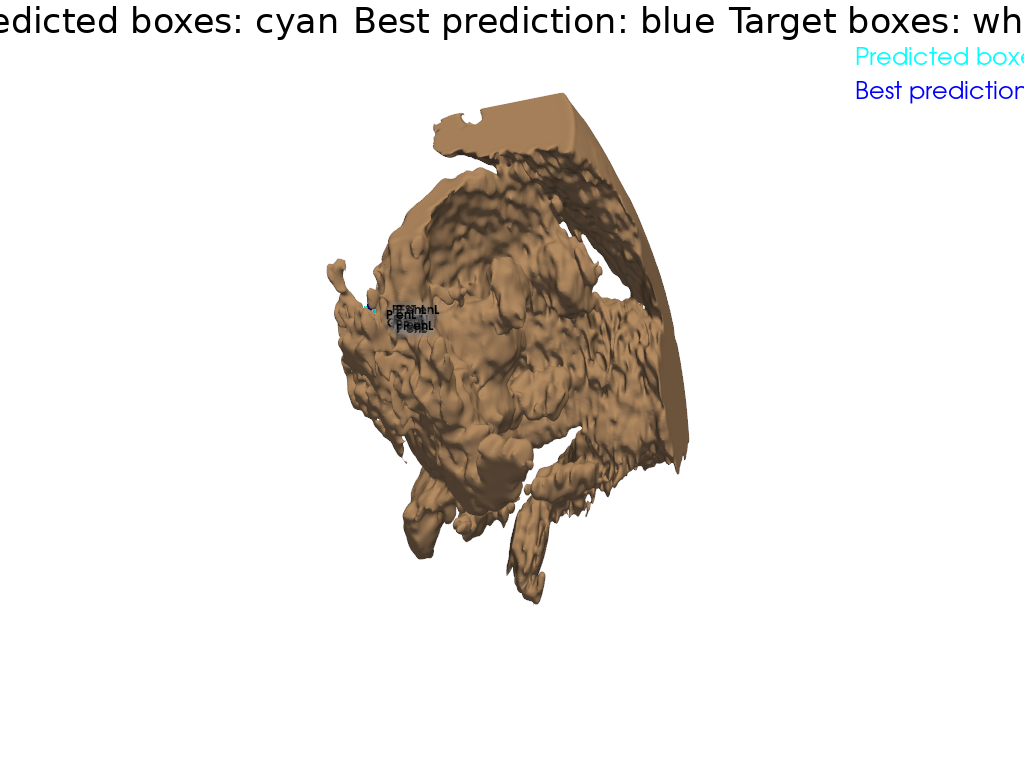

In [ ]:
plot_pred_and_target_boxes_3d(
    pred=pred,
    target=target,
    image=image,
    row=row,
    only_label=4,  # None --> show all labels
    max_pred_boxes=15,
    sphere_radius=0.5,
    export_html_path="temp/explainability_boxes/sample_0_all_labels.html",
)

## 17 Cross-fold Validation

In [ ]:
import gc

for fold in [0, 1, 2]:
    del model, optimizer, train_loader, val_loader, train_dataset, val_dataset
    gc.collect()
    torch.cuda.empty_cache()
    cfg.dataframe_csv = f"/media/yusuf/HDD 4TB/DATA/sinMaternitat__fold{fold}.csv"
    cfg.val_interval = 15
    # print(cfg)
    df = pd.read_csv(cfg.dataframe_csv).reset_index(drop=True)
    df = update_dataframe(df, cfg.root)
    print(df.head())
    print("number of samples:", len(df))
    # print("columns:", list(df.columns))

    assert cfg.image_col in df.columns, f"Missing image column: {cfg.image_col}"
    assert cfg.landmark_col in df.columns, f"Missing landmark column: {cfg.landmark_col}"
    train_idx = df[df["set"] == 0].index.to_numpy()
    val_idx = df[df["set"] == 1].index.to_numpy()
    print("train_idx:", train_idx[:10], "total", len(train_idx))
    print("val_idx:", val_idx[:10], "total", len(val_idx))

    train_dataset = LandmarkDetection3DDataset(
                            dataframe=df.iloc[train_idx].reset_index(drop=True),
                            root=cfg.root,
                            image_col=cfg.image_col,
                            landmark_col=cfg.landmark_col,
                            landmark_columns=cfg.landmark_columns,
                            radius=cfg.radius,
                            transform=None,
                            normalize_image=cfg.normalize_image,
                            num_landmarks=cfg.num_landmarks,
                            )

    val_dataset = LandmarkDetection3DDataset(
                            dataframe=df.iloc[val_idx].reset_index(drop=True),
                            root=cfg.root,
                            image_col=cfg.image_col,
                            landmark_col=cfg.landmark_col,
                            landmark_columns=cfg.landmark_columns,
                            radius=cfg.radius,
                            transform=None,
                            normalize_image=cfg.normalize_image,
                            num_landmarks=cfg.num_landmarks,
                            )

    train_loader = DataLoader(
                    train_dataset,
                    batch_size=cfg.batch_size,
                    shuffle=True,
                    collate_fn=detection_collate,
                    num_workers=cfg.num_workers,
                    pin_memory=torch.cuda.is_available(),
                    )

    val_loader = DataLoader(
                    val_dataset,
                    batch_size=1,
                    shuffle=False,
                    collate_fn=detection_collate,
                    num_workers=cfg.num_workers,
                    pin_memory=torch.cuda.is_available(),
                    )

    print("train batches:", len(train_loader))
    print("val batches:", len(val_loader))
    smoke_index = 0
    image0, target0, row0 = train_dataset[smoke_index]
    print("info:", row0['fcaso'])
    # print("image shape [C,D,H,W]:", tuple(image0.shape))
    # print("points shape:", tuple(target0["points"].shape))
    # print("boxes shape:", tuple(target0["boxes"].shape))
    # print("first 3 points [x,y,z]:")
    # print(target0["points"][:3])
    # print("first 3 boxes [x1,y1,z1,x2,y2,z2]:")
    # print(target0["boxes"][:3])
    print("----------------- GT LOOKUP TABLE ---------------- \n")
    lookup = pd.DataFrame(target0["landmark_names"])
    lookup["categorical"] = np.arange(1,20)
    lookup.set_index("categorical", inplace=True)
    print(lookup)
    print("-------------------------------------------------- \n")
    lookup_dict = lookup.to_dict()[0]
    # print(lookup_dict)
    centers0 = boxes_to_centers_3d(target0["boxes"])
    print("max |box center - point|:", (centers0 - target0["points"]).abs().max().item())
    
    model = TinyMulticlassAnchor3DDetector(
            in_channels=1,
            anchor_sizes=cfg.anchor_sizes,
            num_landmarks=cfg.num_landmarks,
            backbone_channels=cfg.backbone_channels,
            topk_proposals=cfg.topk_proposals,
            ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    # print(model)

    for epoch in range(1, cfg.epochs + 1):
        train_logs = train_one_epoch(model, train_loader, optimizer, device, cfg)
        if epoch == 1 or epoch % cfg.val_interval == 0 or epoch == cfg.epochs:
            val_logs = infer_one_epoch_nms(model, val_loader, device, cfg)
            print(
                f"epoch {epoch:03d} | "
                f"loss {train_logs['loss']:.4f} | "
                f"cls {train_logs['loss_anchor_cls']:.4f} | "
                f"reg {train_logs['loss_anchor_reg']:.4f} | "
                f"pos {train_logs['num_pos']:.1f} | "
                f"neg {train_logs['num_neg']:.1f} | "
                f"any mean {val_logs['proposal_center_mean_error_vox']:.2f} vox | "
                f"class mean {val_logs['class_matched_mean_error_vox']:.2f} vox | "
                f"class coverage {val_logs['class_prediction_coverage']:.2%}"
            )

    torch.save({"model_state": model.state_dict(), "cfg": asdict(cfg)}, f"temp/multiclass_anchor3d_deep{fold}.pt")
    ckpt = torch.load(f"temp/multiclass_anchor3d_deep{fold}.pt", map_location=device)
    print("after training & nms:", json.dumps(infer_one_epoch_nms(model, val_loader, device, cfg), indent=2))


NameError: name 'model' is not defined

In [ ]:
q